In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Exercise Pandas

For these exercices we are using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data/kernels) provided by Airbnb for a Kaggle competition. It describes its offer for New York City in 2019, including types of appartments, price, location etc.

## 1. Create a dataframe 
Create a dataframe of a few lines with objects and their poperties (e.g fruits, their weight and colour).
Calculate the mean of your Dataframe.

In [3]:
fruit_df = pd.DataFrame({
    "Fruit" : ["Apple", "Banana", "Orange", "Grapes"],
    "Weight" : [150, 120, 180, 50],
    "Color_Code" : [1, 2, 3, 4]
})

fruit_df

,Fruit,Weight,Color_Code
0,Apple,150,1
1,Banana,120,2
2,Orange,180,3
3,Grapes,50,4


In [4]:
mean_values = fruit_df.mean(numeric_only=True)
mean_values

Weight        125.0
Color_Code      2.5
dtype: float64

## 2. Import
- Import the table called ```AB_NYC_2019.csv``` as a dataframe. It is located in the Datasets folder. Have a look at the beginning of the table (head).

- Create a histogram of prices

In [5]:
path = r"D:\AICourseTahlildadeh\HW1\AB_NYC_2019.csv"
df = pd.read_csv(path)

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


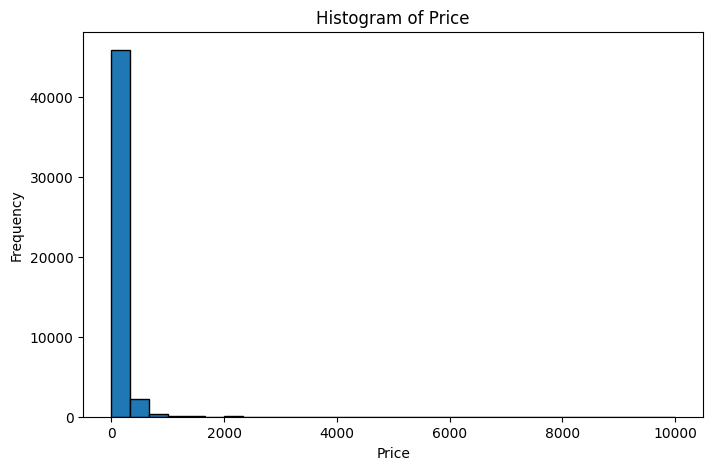

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=30, edgecolor='black')
plt.title("Histogram of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## 3. Operations

Create a new column in the dataframe by multiplying the "price" and "availability_365" columns to get an estimate of the maximum yearly income.

In [7]:
df["maximum_yearly_income"] = df["price"] * df["availability_365"]
df[["price", "availability_365", "maximum_yearly_income"]].head()

,price,availability_365,maximum_yearly_income
0,149,365,54385
1,225,355,79875
2,150,365,54750
3,89,194,17266
4,80,0,0


## 3b. Subselection and plotting
Create a new Dataframe by first subselecting yearly incomes between 1 and 100'000. Then make a scatter plot of yearly income versus number of reviews 

In [18]:
df_income = df[(df["maximum_yearly_income"] >= 1) & (df["maximum_yearly_income"] <= 100000)]
df_income.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,maximum_yearly_income,population_x,population_y,population
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,54385,2559903,2559903,2559903
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,79875,1628706,1628706,1628706
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365,54750,1628706,1628706,1628706
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,17266,2559903,2559903,2559903
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129,25800,1628706,1628706,1628706


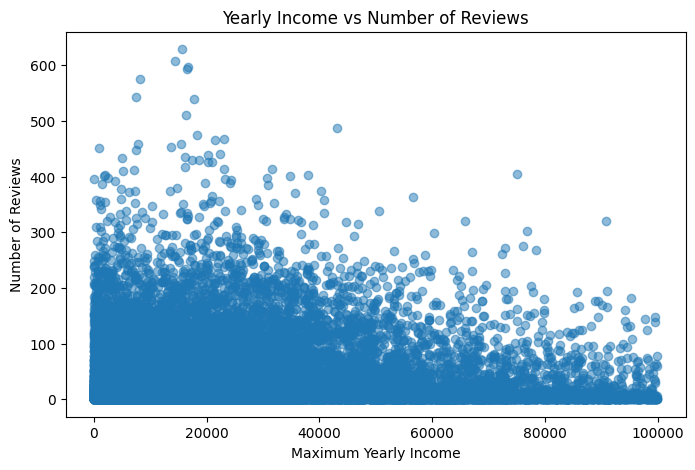

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df_income["maximum_yearly_income"], df_income["number_of_reviews"], alpha=0.5)
plt.title("Yearly Income vs Number of Reviews")
plt.xlabel("Maximum Yearly Income")
plt.ylabel("Number of Reviews")
plt.show()

## 4. Combine

We provide below and additional table that contains the number of inhabitants of each of New York's boroughs ("neighbourhood_group" in the table). Use ```merge``` to add this population information to each element in the original dataframe.

In [ ]:
df = df.drop(columns=['population', 'population_x', 'population_y'], errors='ignore')

population_df = pd.DataFrame({
    'neighbourhood_group': ['Brooklyn', 'Manhattan'],
    'population': [2559903, 1628706]
})

df = df.merge(population_df, on='neighbourhood_group', how='left')

df[['neighbourhood_group', 'population']].head(10)

,neighbourhood_group,population
0,Brooklyn,2559903.0
1,Manhattan,1628706.0
2,Manhattan,1628706.0
3,Brooklyn,2559903.0
4,Manhattan,1628706.0
5,Manhattan,1628706.0
6,Brooklyn,2559903.0
7,Manhattan,1628706.0
8,Manhattan,1628706.0
9,Manhattan,1628706.0


## 5. Groups

- Using ```groupby``` calculate the average price for each type of room (room_type) in each neighbourhood_group. What is the average price for an entire home in Brooklyn ?
- Unstack the multi-level Dataframe into a regular Dataframe with ```unstack()``` and create a bar plot with the resulting table


In [26]:
avg_price = df.groupby(['neighbourhood_group', 'room_type'])['price'].mean()
avg_price

neighbourhood_group  room_type      
Bronx                Entire home/apt    127.506596
                     Private room        66.788344
                     Shared room         59.800000
Brooklyn             Entire home/apt    178.327545
                     Private room        76.500099
                     Shared room         50.527845
Manhattan            Entire home/apt    249.239109
                     Private room       116.776622
                     Shared room         88.977083
Queens               Entire home/apt    147.050573
                     Private room        71.762456
                     Shared room         69.020202
Staten Island        Entire home/apt    173.846591
                     Private room        62.292553
                     Shared room         57.444444
Name: price, dtype: float64

In [27]:
print(avg_price.loc[('Brooklyn', 'Entire home/apt')])

178.32754472225128


In [28]:
avg_price_df = avg_price.unstack()
avg_price_df

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,127.506596,66.788344,59.800000
Brooklyn,178.327545,76.500099,50.527845
Manhattan,249.239109,116.776622,88.977083
Queens,147.050573,71.762456,69.020202
Staten Island,173.846591,62.292553,57.444444


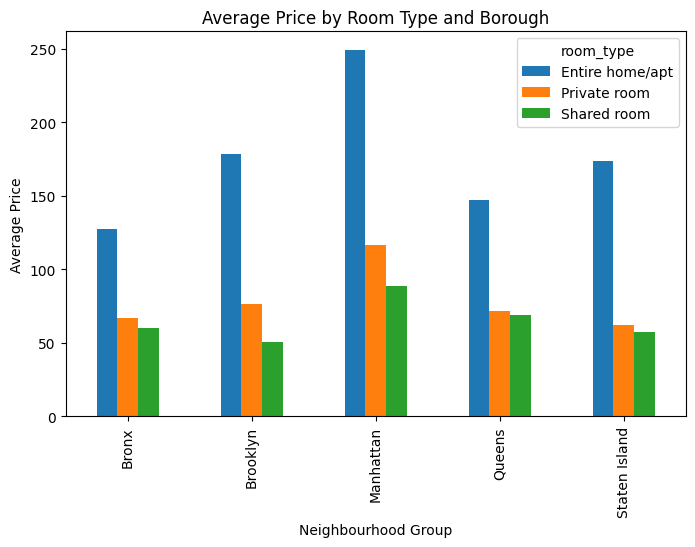

In [29]:
avg_price_df.plot(kind='bar', figsize=(8, 5))

plt.title('Average Price by Room Type and Borough')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price')
plt.show()

## 6. Advanced plotting

Using Seaborn, create a scatter plot where x and y positions are longitude and lattitude, the color reflects price and the shape of the marker the borough (neighbourhood_group). Can you recognize parts of new york ? Does the map make sense ?

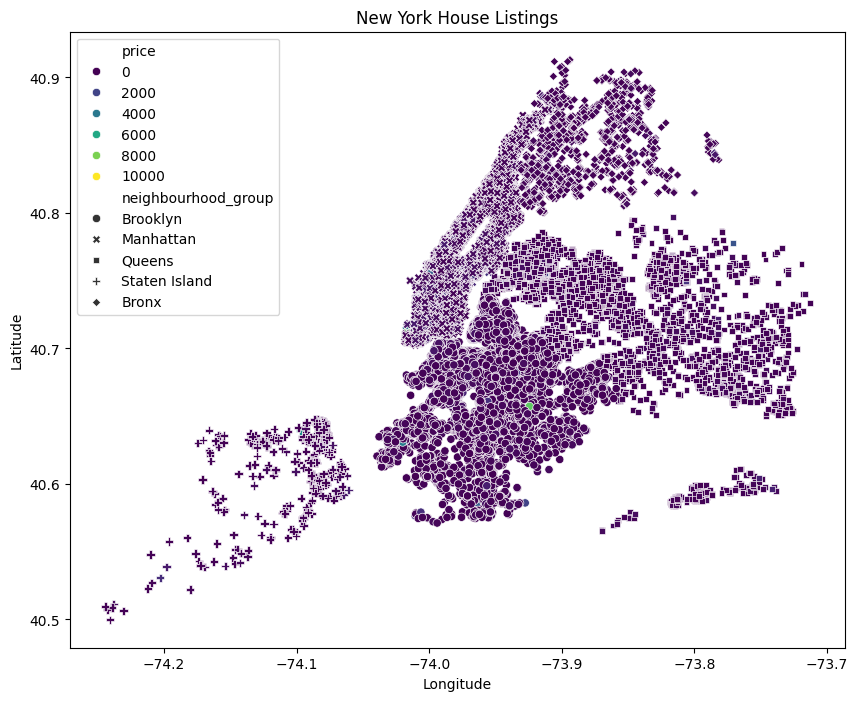

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='price',                 
    style='neighbourhood_group',  
    palette='viridis'
)

plt.title('New York House Listings')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

<div dir="rtl" style="text-align: right">
<b> تحلیل نتایج </b>

بله، این نمودار تا حد زیادی شبیه نقشه شهر نیویورک است. بخش‌های مختلف شهر را می‌توان از روی موقعیت نقاط و شکل نشانگرها تشخیص داد. منهتن به صورت یک جزیره باریک و کشیده در مرکز دیده می‌شود، بروکلین در جنوب شرقی آن قرار دارد، کویینز در سمت شرق گسترده شده است، برانکس در شمال منهتن قرار دارد و استیتن آیلند به صورت یک خوشه جداگانه در جنوب غربی دیده می‌شود.

این نقشه منطقی به نظر می‌رسد، زیرا مختصات طول و عرض جغرافیایی موقعیت واقعی آگهی‌ها را حفظ کرده‌اند. پراکندگی نقاط شکل کلی شهر نیویورک را نشان می‌دهد و رنگ نقاط نیز بیانگر تفاوت قیمت‌ها است؛ به‌طوری‌که آگهی‌های گران‌تر بیشتر در برخی مناطق، به‌ویژه منهتن، متمرکز هستند و بیشتر آگهی‌ها قیمت‌های پایین‌تری دارند. در مجموع، این نمودار هم از نظر موقعیت جغرافیایی و هم از نظر توزیع قیمت‌ها با واقعیت سازگار است.
</div>